### Fish velocity calculation from trajectories
To calculate the velocity of the fish from the $x$ and $y$ locations, you need to compute the displacement between consecutive points ($Delta x$, $\Delta y$) and divide by the corresponding time interval ($\Delta t$). 
Velocity Calculation: 
$$V=\frac{\sqrt(\Delta x^2+\Delta y^2)}{\Delta t}$$

The following script will calculate the velocities based on the trajectories and save it to an excel file.

First few rows of the dataset:
       x       y
0  4.927 -0.2992
1  5.278 -0.2992
2  5.044 -0.3672
3  5.044 -0.4896
4  5.044 -0.4896

First few rows with velocity calculation:
       x       y     dx      dy     dt  velocity   direction
0  4.927 -0.2992    NaN     NaN  0.037       NaN         NaN
1  5.278 -0.2992  0.351  0.0000  0.037  9.486486    0.000000
2  5.044 -0.3672 -0.234 -0.0680  0.037  6.585949 -163.796226
3  5.044 -0.4896  0.000 -0.1224  0.037  3.308108  -90.000000
4  5.044 -0.4896  0.000  0.0000  0.037  0.000000    0.000000


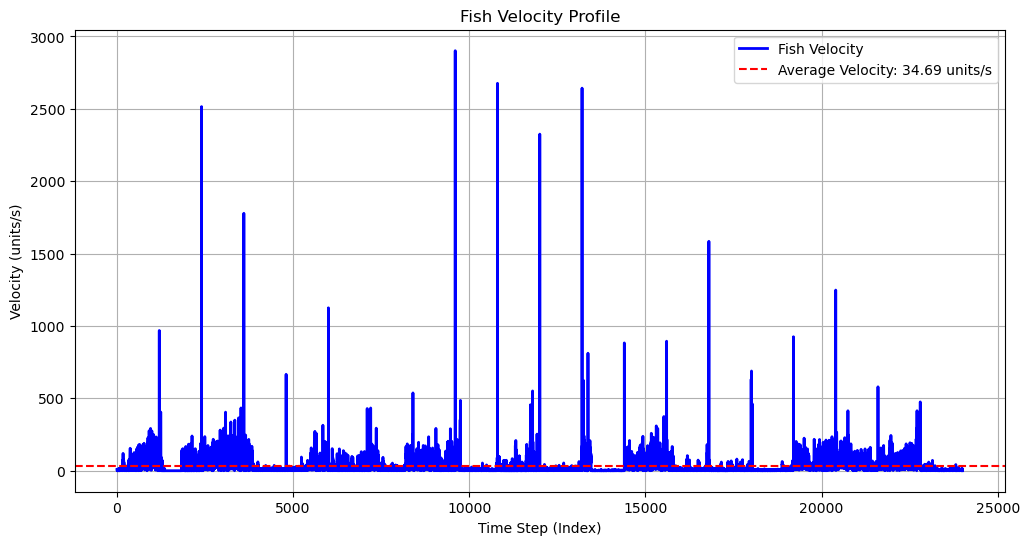


Velocity results saved to 'fish_velocity_output-MS.xlsx'.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file (replace 'fish_locations.xlsx' with your actual file name)
file_path = 'MS.xlsx'  # Update with your file path
df = pd.read_excel(file_path)

# Display the first few rows to verify the data structure
print("First few rows of the dataset:")
print(df.head())

# Ensure the DataFrame has 'x' and 'y' columns
if 'x' not in df.columns or 'y' not in df.columns:
    raise ValueError("The Excel file must contain 'x' and 'y' columns.")

# Calculate displacement between consecutive points
df['dx'] = df['x'].diff()
df['dy'] = df['y'].diff()

# If time data is available, use it; otherwise, assume constant time step
if 'time' in df.columns:
    df['dt'] = df['time'].diff()
else:
    time_step = 0.037  # framerate f=27 Hz, dt=1/f
    df['dt'] = time_step

# Calculate velocity magnitude (in units per second)
df['velocity'] = np.sqrt(df['dx']**2 + df['dy']**2) / df['dt']

# Calculate movement direction (angle in degrees)
df['direction'] = np.degrees(np.arctan2(df['dy'], df['dx']))

# Display the first few rows with calculated velocity
print("\nFirst few rows with velocity calculation:")
print(df[['x', 'y', 'dx', 'dy', 'dt', 'velocity', 'direction']].head())

# Plot the velocity profile
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['velocity'], color='b', linewidth=2, label='Fish Velocity')
plt.axhline(y=df['velocity'].mean(), color='r', linestyle='--', label=f'Average Velocity: {df["velocity"].mean():.2f} units/s')
plt.xlabel('Time Step (Index)')
plt.ylabel('Velocity (units/s)')
plt.title('Fish Velocity Profile')
plt.legend()
plt.grid(True)
plt.show()

# Save the results to a new Excel file
output_file = 'fish_velocity_output-MS.xlsx'
df.to_excel(output_file, index=False)
print(f"\nVelocity results saved to '{output_file}'.")


### Critical burst swimming speed of fish
<img src="cbbs.png" alt="CBSS" width="1000"/>

First, you need to add the swimming speed from the tracking to the average flow velocity of the area they are swimming in (here $U_{\infty}$). Then, you have to cap it at CBSS of 15.7 $BL/s$ or 1 $m/s$.


Adjusted velocity data saved to 'fish_velocity_adjusted_MR.xlsx'
Average velocity: 42.68 cm/s
Maximum velocity: 100.00 cm/s
Percentage swimming against flow: 78.3%
Regional statistics saved to 'regional_statistics_HR.xlsx'


C:\Users\Student\AppData\Local\Temp\ipykernel_20540\44566442.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(['x_bin', 'y_bin']).agg(


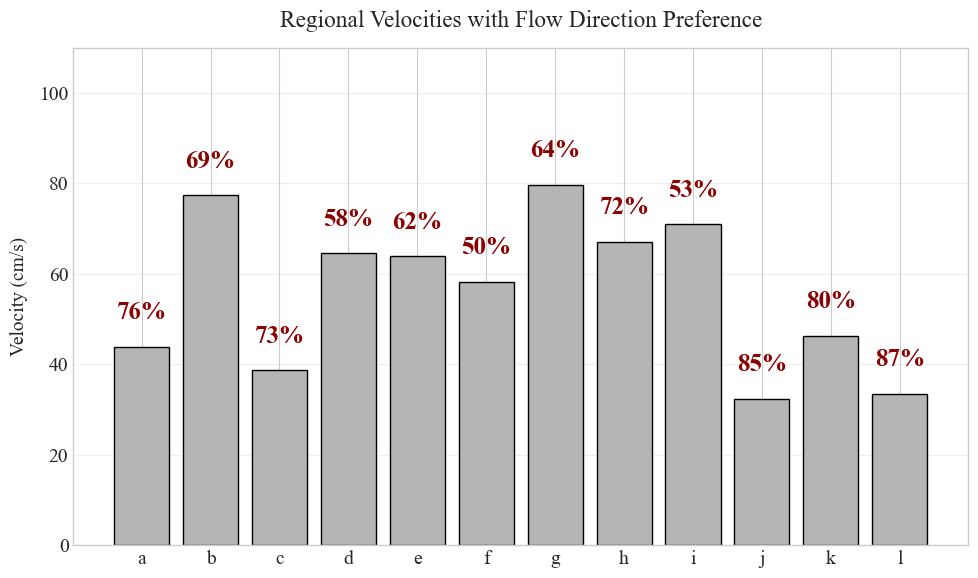

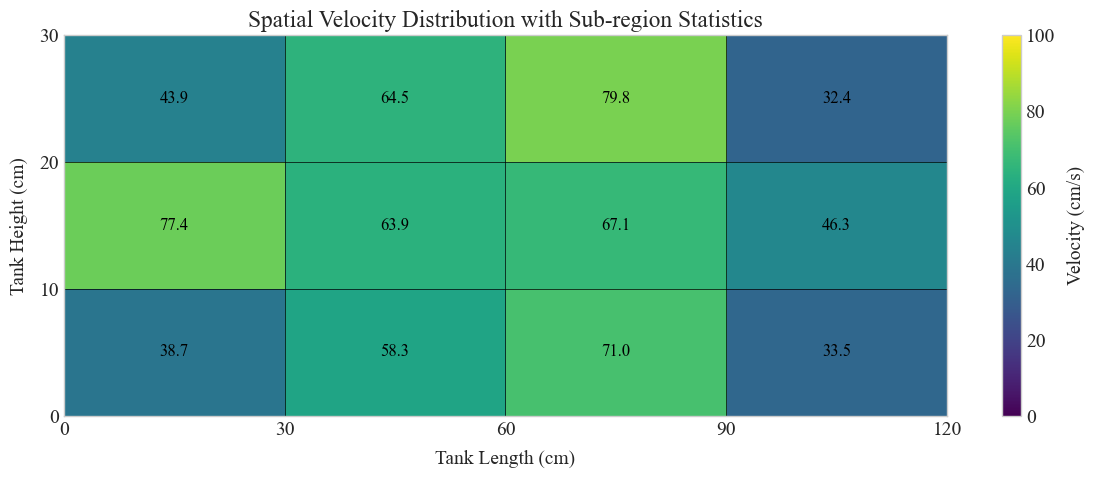

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import string
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

# ========================
# Configuration
# ========================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 14,
    'axes.labelpad': 8,
})

# ========================
# Data Processing
# ========================
# Load and process data
file_path = 'HR.xlsx'
df = pd.read_excel(file_path)

# Extract base name from input file
base_name = file_path.split('.')[0]

# Coordinate transformations
df['x_flipped'] = 120 - df['x']  # Horizontal flip (left-right)
df['y_flipped'] = 30 - df['y']   # Vertical flip (top-bottom)

# Velocity calculation
FLOW_VELOCITY = 19  # cm/s
CBSS_THRESHOLD = 100
dt = 0.037  # 27Hz

# Make sure dt is a proper column, not just a scalar value
if 'dt' not in df.columns:
    df['dt'] = dt  # This will create a column with the value repeated for all rows

df['dx_adj'] = df['x_flipped'].diff() - (FLOW_VELOCITY * dt)
df['dy_adj'] = df['y_flipped'].diff()
df['velocity'] = np.sqrt(df['dx_adj']**2 + df['dy_adj']**2) / dt
df['velocity'] = np.clip(df['velocity'], 0, CBSS_THRESHOLD)

# Save the adjusted velocity data to a new Excel file
velocity_output_file = 'fish_velocity_adjusted_MR.xlsx'
velocity_columns = ['x', 'y', 'x_flipped', 'y_flipped', 'dx_adj', 'dy_adj', 'dt', 'velocity']

# Create a new DataFrame with only the columns we want to save
velocity_df = df[velocity_columns].copy()

# Add a relative x-velocity column (negative = swimming against flow, positive = with flow)
velocity_df['x_velocity_rel'] = df['dx_adj'] / dt

# Add the flow direction as a categorical column for easier analysis
velocity_df['flow_direction'] = np.where(velocity_df['x_velocity_rel'] < 0, 
                                        'against_flow', 
                                        'with_flow')

# Save to Excel
velocity_df.to_excel(velocity_output_file, index=False)
print(f"\nAdjusted velocity data saved to '{velocity_output_file}'")

# Display basic statistics about the adjusted velocity data
print(f"Average velocity: {velocity_df['velocity'].mean():.2f} cm/s")
print(f"Maximum velocity: {velocity_df['velocity'].max():.2f} cm/s")
print(f"Percentage swimming against flow: {(velocity_df['x_velocity_rel'] < 0).mean()*100:.1f}%")

# ========================
# Spatial Analysis
# ========================
# Create bins and labels
x_bins = np.linspace(0, 120, 5)  # 4 columns
y_bins = np.linspace(0, 30, 4)   # 3 rows

# Assign bins: x from left to right, y with manual labels to invert the order
df['x_bin'] = pd.cut(df['x_flipped'], bins=x_bins, labels=[1, 2, 3, 4])
df['y_bin'] = pd.cut(df['y_flipped'], bins=y_bins, labels=[3, 2, 1])

# Calculate regional statistics
stats = df.groupby(['x_bin', 'y_bin']).agg(
    mean_velocity=('velocity', 'mean'),
    median_velocity=('velocity', 'median'),
    min_velocity=('velocity', 'min'),
    max_velocity=('velocity', 'max'),
    std_velocity=('velocity', 'std'),
    percentile_25=('velocity', lambda x: x.quantile(0.25)),
    percentile_75=('velocity', lambda x: x.quantile(0.75)),
    against_flow_ratio=('dx_adj', lambda x: (x < 0).mean())
).reset_index()

# Sort and label regions in column-major order (left-to-right, then top-to-bottom)
stats = stats.sort_values(['x_bin', 'y_bin'], ascending=[True, False])
stats['region'] = list(string.ascii_lowercase[:len(stats)])

# Export statistics to an Excel file
stats_output_file = f'regional_statistics_{base_name}.xlsx'
stats.to_excel(stats_output_file, index=False)
print(f"Regional statistics saved to '{stats_output_file}'")

# ========================
# Visualization: Figure 1 - Bar Chart
# ========================
fig1 = plt.figure(figsize=(10, 6))
gs = GridSpec(nrows=1, ncols=1, figure=fig1) 
ax1 = fig1.add_subplot(gs[0, 0])
colors = plt.cm.viridis(np.linspace(0, 1, len(stats))) # replace the colors with the color code if you want to have specific colors

bars = ax1.bar(stats['region'], stats['mean_velocity'], 
               # yerr=stats['std_velocity'],  # <-- Removed error bars
               color='#b6b4b4', edgecolor='k', capsize=5)

# Add flow ratio annotation above the bar only
for i, row in stats.iterrows():
    bar = bars[i]
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f"{row['against_flow_ratio']*100:.0f}%", 
             ha='center', va='bottom', color='darkred', fontsize=18, fontweight='bold')

ax1.set_title('Regional Velocities with Flow Direction Preference', pad=15)
ax1.set_ylabel('Velocity (cm/s)')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', alpha=0.3)
fig1.tight_layout()
plt.savefig(f'spatial_distribution1_{base_name}.png', dpi=300)

# ========================
# Visualization: Figure 2 - Spatial Velocity Distribution
# ========================
fig2, ax2 = plt.subplots(figsize=(12, 5))

# Compute grid centers for text annotations
x_centers = [(x_bins[i] + x_bins[i+1])/2 for i in range(len(x_bins)-1)]
y_centers = [(y_bins[i] + y_bins[i+1])/2 for i in range(len(y_bins)-1)]

# Create velocity grid matrix (rows: y, columns: x)
velocity_grid = np.full((3, 4), np.nan)  # 3 rows (y) x 4 columns (x)
for _, row in stats.iterrows():
    x_idx = int(row['x_bin']) - 1
    y_idx = 3 - int(row['y_bin'])  # since y_bin was labeled [3,2,1] for top-to-bottom
    velocity_grid[y_idx, x_idx] = row['mean_velocity']

# Plot heatmap of mean velocities
im = ax2.imshow(velocity_grid, 
                cmap='viridis', 
                extent=[0, 120, 0, 30],
                aspect='auto',
                origin='lower',
                vmin=0, vmax=100)

# Set ticks only at bin edges
ax2.set_xticks(x_bins)  # Set x-axis ticks at bin edges
ax2.set_yticks(y_bins)  # Set y-axis ticks at bin edges

# Annotate each sub-region with mean velocity
for _, row in stats.iterrows():
    x_idx = int(row['x_bin']) - 1
    y_idx = 3 - int(row['y_bin'])
    x_pos = x_centers[x_idx]
    y_pos = y_centers[y_idx]
    
    # Mean velocity value in the center of the bin
    ax2.text(x_pos, y_pos, f"{row['mean_velocity']:.1f}", 
             color='black', ha='center', va='center', fontsize=12)
    
# Add grid lines at the bin edges
ax2.grid(visible=True, color='black', linestyle='-', linewidth=0.5)

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Velocity (cm/s)')

ax2.set_title('Spatial Velocity Distribution with Sub-region Statistics')
ax2.set_xlabel('Tank Length (cm)')
ax2.set_ylabel('Tank Height (cm)')

plt.tight_layout()
plt.savefig(f'spatial_distribution_{base_name}.png', dpi=300)
plt.show()


We need to understand how fish move in relation to water flow in different regions of an experimental channel. To this, we need to quantify Flow distribution preference, which tells us how frequently fish swim against the water current (upstream) versus with the flow (downstream) in specific regions of the tank. It is calculated as the percentage of time the fish exhibits active swimming against the flow in each region.
We will end up with directional velocity component which is the x-velocity relative to water (u_water_rel = dx_adj / dt).
Negative u_water_rel: Fish is swimming against the flow, and positive u_water_rel: Fish is swimming with the flow.
#### Key measurements:
Where does the fish swim fastest?

How often does it fight the current vs. drift with the flow?

Which regions require the most energy expenditure (high velocity + high against-flow ratio)?

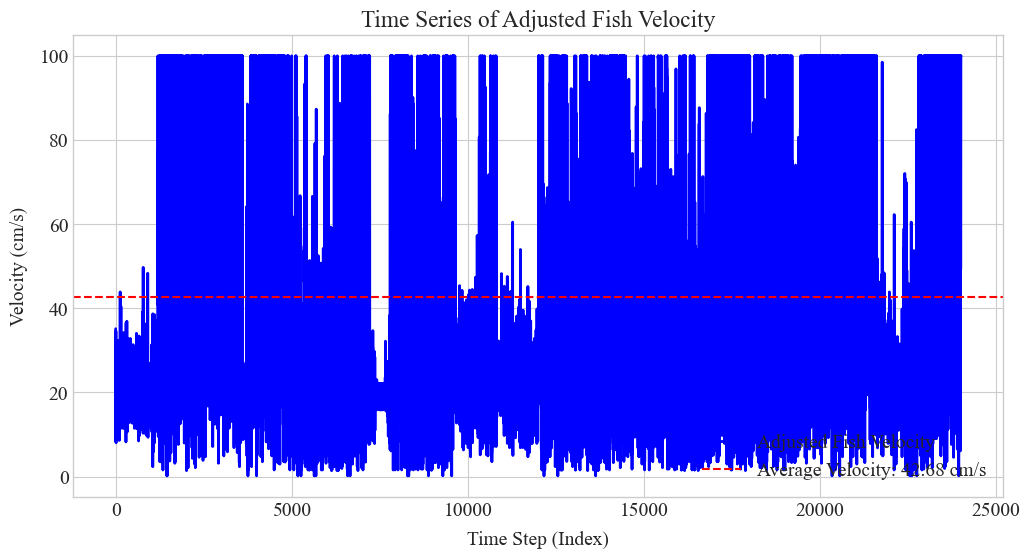

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the adjusted velocity data from the Excel file
file_path = 'fish_velocity_adjusted_MR.xlsx'
df = pd.read_excel(file_path)

average_velocity = df['velocity'].mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['velocity'], color='b', linewidth=2, label='Adjusted Fish Velocity')
plt.axhline(y=average_velocity, color='r', linestyle='--', 
            label=f'Average Velocity: {average_velocity:.2f} cm/s')
plt.xlabel('Time Step (Index)')
plt.ylabel('Velocity (cm/s)')
plt.title('Time Series of Adjusted Fish Velocity')
plt.legend()
plt.grid(True)
plt.show()

using the calculated fish velocitites, thrust forces can be calculated as follows:

$$T_f=\rho_f V_f^2 L_f^2$$

In [21]:
# ---------------------------------------------
# Calculate Thrust force and update the file
# Thrust force: T_f = ρ_f * velocity^2 * L_f^2
# ---------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

# Load the adjusted velocity data from the Excel file
file_path = 'fish_velocity_adjusted_MR.xlsx'
velocity_df = pd.read_excel(file_path)

# Example constants (update as needed)
rho_f = 1.08   # fish density (g/cm^3)
L_f = 6    # fish length (cm)

# Compute thrust force using the 'velocity' column
velocity_df['thrust_force'] = rho_f * (velocity_df['velocity'] ** 2) * (L_f ** 2)

# Save the updated DataFrame with the new 'thrust_force' column
velocity_df.to_excel(file_path, index=False)
print(f"Updated file with thrust force saved to '{file_path}'")

Updated file with thrust force saved to 'fish_velocity_adjusted_MR.xlsx'


Then, here we can find the mean force at each subregion:

In [22]:
import pandas as pd
import numpy as np

# Load the adjusted velocity data with thrust force
file_path = 'fish_velocity_adjusted_MR.xlsx'
df = pd.read_excel(file_path)

# Create bins and labels
x_bins = np.linspace(0, 120, 5)  # 4 columns
y_bins = np.linspace(0, 30, 4)   # 3 rows

# Assign bins: x from left to right, y with manual labels to invert the order
df['x_bin'] = pd.cut(df['x_flipped'], bins=x_bins, labels=[1, 2, 3, 4])
df['y_bin'] = pd.cut(df['y_flipped'], bins=y_bins, labels=[3, 2, 1])

# Calculate comprehensive statistics for both velocity and thrust force by region
combined_stats = df.groupby(['x_bin', 'y_bin']).agg(
    # Velocity statistics
    mean_velocity=('velocity', 'mean'),
    median_velocity=('velocity', 'median'),
    std_velocity=('velocity', 'std'),
    min_velocity=('velocity', 'min'),
    max_velocity=('velocity', 'max'),
    # Thrust force statistics
    mean_thrust_force=('thrust_force', 'mean'),
    median_thrust_force=('thrust_force', 'median'),
    std_thrust_force=('thrust_force', 'std'),
    min_thrust_force=('thrust_force', 'min'),
    max_thrust_force=('thrust_force', 'max')
).reset_index()

print("Combined Velocity and Thrust Force Statistics by Subregion:")
print("=" * 80)
for _, row in combined_stats.iterrows():
    print(f"\nSubregion (x_bin={row['x_bin']}, y_bin={row['y_bin']}):")
    print(f"  Velocity     - Mean: {row['mean_velocity']:.2f} cm/s, Std: {row['std_velocity']:.2f} cm/s")
    print(f"  Thrust Force - Mean: {row['mean_thrust_force']:.2f} g⋅cm²/s², Std: {row['std_thrust_force']:.2f} g⋅cm²/s²")
    print(f"  Velocity Range: {row['min_velocity']:.2f} - {row['max_velocity']:.2f} cm/s")
    print(f"  Thrust Range: {row['min_thrust_force']:.2f} - {row['max_thrust_force']:.2f} g⋅cm²/s²")

print("\n" + "=" * 80)
print("Summary Table:")
print(combined_stats[['x_bin', 'y_bin', 'mean_velocity', 'mean_thrust_force']].round(2))

# Show the relationship between velocity and thrust force
print("\n" + "=" * 80)
print("Velocity vs Thrust Force Relationship:")
print("(Note: Thrust Force = ρ_f × velocity² × L_f²)")
for _, row in combined_stats.iterrows():
    theoretical_thrust = 1.08 * (row['mean_velocity'] ** 2) * (6 ** 2)
    print(f"Bin ({row['x_bin']}, {row['y_bin']}): Velocity={row['mean_velocity']:.2f} cm/s → Thrust={theoretical_thrust:.2f} g⋅cm²/s²")

Combined Velocity and Thrust Force Statistics by Subregion:

Subregion (x_bin=1.0, y_bin=3.0):
  Velocity     - Mean: 38.69 cm/s, Std: 29.02 cm/s
  Thrust Force - Mean: 90937.54 g⋅cm²/s², Std: 120928.98 g⋅cm²/s²
  Velocity Range: 0.17 - 100.00 cm/s
  Thrust Range: 1.16 - 388800.00 g⋅cm²/s²

Subregion (x_bin=1.0, y_bin=2.0):
  Velocity     - Mean: 77.41 cm/s, Std: 28.94 cm/s
  Thrust Force - Mean: 265407.53 g⋅cm²/s², Std: 144048.73 g⋅cm²/s²
  Velocity Range: 2.35 - 100.00 cm/s
  Thrust Range: 215.53 - 388800.00 g⋅cm²/s²

Subregion (x_bin=1.0, y_bin=1.0):
  Velocity     - Mean: 43.87 cm/s, Std: 31.81 cm/s
  Thrust Force - Mean: 114158.54 g⋅cm²/s², Std: 137574.74 g⋅cm²/s²
  Velocity Range: 0.17 - 100.00 cm/s
  Thrust Range: 1.16 - 388800.00 g⋅cm²/s²

Subregion (x_bin=2.0, y_bin=3.0):
  Velocity     - Mean: 58.30 cm/s, Std: 32.91 cm/s
  Thrust Force - Mean: 174216.19 g⋅cm²/s², Std: 151726.61 g⋅cm²/s²
  Velocity Range: 0.17 - 100.00 cm/s
  Thrust Range: 1.16 - 388800.00 g⋅cm²/s²

Subregion 

C:\Users\Student\AppData\Local\Temp\ipykernel_20540\2318373161.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_stats = df.groupby(['x_bin', 'y_bin']).agg(
